<a href="https://colab.research.google.com/github/Goreds17/Hannah-Dean-Portfolio/blob/main/Future_Value_Natural_Language_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries

In [ ]:
import os
import re
import glob
import zipfile
import nltk
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score
)
from nltk.stem import WordNetLemmatizer

Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()

zip_filename = "fg_reports_txt.zip"
extract_folder = "fg_reports_txt"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

folder_path = "fg_reports_txt/fg_reports_txt"
all_files = glob.glob(os.path.join(folder_path, "*.txt"))

print("Found files:", len(all_files))

Saving fg_reports_txt.zip to fg_reports_txt.zip
Found files: 543


Parse Files

In [ ]:
def parse_prospect_file(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    name_match = re.search(r"Name:\s*(.*)", text)
    pos_match = re.search(r"Position:\s*(.*)", text)
    fv_match = re.search(r"FV:\s*(.*)", text)
    risk_match = re.search(r"Risk:\s*(.*)", text)
    report_match = re.search(r"Report:\s*(.*)", text, re.DOTALL)

    return {
        "file": os.path.basename(filepath),
        "name": name_match.group(1).strip() if name_match else None,
        "position": pos_match.group(1).strip() if pos_match else None,
        "FV_raw": fv_match.group(1).strip() if fv_match else None,
        "Risk_raw": risk_match.group(1).strip() if risk_match else None,
        "report": report_match.group(1).strip() if report_match else None
    }

records = [parse_prospect_file(file) for file in all_files]
df = pd.DataFrame(records)

print(df.head())
print(df.shape)

                  file             name position FV_raw Risk_raw  \
0   Matthew Fisher.txt   Matthew Fisher       SP     45     High   
1         Joe Mack.txt         Joe Mack        C     50     High   
2      Angel Nuñez.txt      Angel Nuñez       CF    40+     High   
3      Talon Haley.txt      Talon Haley       SP     40     High   
4  Anderson Araujo.txt  Anderson Araujo        C     40      Med   

                                              report  
0  Fisher, who is from the same part of Indiana a...  
1  Mack is among the top catching prospects in ba...  
2  Nuñez is a twitchy, smedium-framed center fiel...  
3  Haley is an explosive lefty with arm strength,...  
4  Araujo is a bat-first catching prospect who ha...  
(543, 6)


Label Cleaning

In [ ]:
def convert_fv_to_numeric(fv):
    if pd.isna(fv):
        return np.nan
    fv = str(fv).strip()

    plus_match = re.match(r"(\d+)\+", fv)
    plain_match = re.match(r"(\d+)$", fv)

    if plus_match:
        return float(plus_match.group(1)) + 0.5
    elif plain_match:
        return float(plain_match.group(1))
    else:
        return np.nan

def encode_risk(risk):
    if pd.isna(risk):
        return np.nan

    risk = str(risk).strip().lower()
    mapping = {"low": 0, "med": 1, "medium": 1, "high": 2}
    return mapping.get(risk, np.nan)

df["FV"] = df["FV_raw"].apply(convert_fv_to_numeric)
df["Risk"] = df["Risk_raw"].apply(encode_risk)

print(df[["FV_raw", "FV", "Risk_raw", "Risk"]].head())

  FV_raw    FV Risk_raw  Risk
0     45  45.0     High     2
1     50  50.0     High     2
2    40+  40.5     High     2
3     40  40.0     High     2
4     40  40.0      Med     1


NLTK Downloads

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Custom Stopwords

In [ ]:
custom_stopwords = set(ENGLISH_STOP_WORDS)

extra_stopwords = {
    "year", "years", "old", "one", "two", "three",
    "also", "still", "really", "bit", "lot", "well",
    "get", "gets", "got", "made", "make", "making",
    "go", "goes", "going", "come", "comes", "came",
    "player"
}

keep_words = {
    "up", "down", "off", "out", "over", "under",
    "tool", "tools", "power", "arm", "bat", "hit",
    "run", "runner", "fastball", "slider", "changeup",
    "curveball", "command", "control", "velo", "velocity",
    "shortstop", "catcher", "center", "field", "starter",
    "reliever", "role", "utility", "strike", "zone",
    "not", "no", "never", "without", "nor",
    "lack", "lacks", "lacking", "less"
}

custom_stopwords = (custom_stopwords | extra_stopwords) - keep_words

Pre-Processing

In [ ]:
def mask_player_name(text, name):
    if pd.isna(text):
        return ""
    if pd.isna(name):
        return str(text).lower()

    text = str(text)
    name = str(name).strip().lower()
    masked_text = text.lower()

    masked_text = re.sub(rf"\b{re.escape(name)}\b", "PLAYER", masked_text)

    for part in name.split():
        if len(part) > 1:
            masked_text = re.sub(rf"\b{re.escape(part)}\b", "PLAYER", masked_text)

    return masked_text

def attach_negation(tokens):
    negation_words = {"not", "no", "never", "without", "nor"}
    new_tokens = []
    i = 0

    while i < len(tokens):
        token = tokens[i]
        if token in negation_words and i + 1 < len(tokens):
            new_tokens.append(f"{token}_{tokens[i+1]}")
            i += 2
        else:
            new_tokens.append(token)
            i += 1

    return new_tokens

lemmatizer = WordNetLemmatizer()

def preprocess_scouting_report(text, name=None, use_lemmatization=True):
    if pd.isna(text):
        return ""

    text = mask_player_name(text, name)
    text = re.sub(r"[^a-zA-Z0-9\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    tokens = re.findall(r"[a-z0-9]+(?:-[a-z0-9]+)*", text)

    cleaned_tokens = []

    for token in tokens:
        if len(token) <= 1:
            continue
        if token in custom_stopwords:
            continue

        if use_lemmatization:
            if "-" in token:
                parts = token.split("-")
                parts = [lemmatizer.lemmatize(part) for part in parts]
                token = "-".join(parts)
            else:
                token = lemmatizer.lemmatize(token)

        cleaned_tokens.append(token)

    cleaned_tokens = attach_negation(cleaned_tokens)

    return " ".join(cleaned_tokens)

df["clean_report"] = df.apply(
    lambda row: preprocess_scouting_report(row["report"], row["name"]),
    axis=1
)

Check Point

In [ ]:
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print("NAME:", df.iloc[i]["name"])
    print("ORIGINAL:", df.iloc[i]["report"][:300])
    print("CLEANED:", df.iloc[i]["clean_report"][:300])


--- Example 1 ---
NAME: Matthew Fisher
ORIGINAL: Fisher, who is from the same part of Indiana as the Mattingly family, ranked 32nd on the 2025 Draft Board but signed for $1.25 million (the slot value of pick 68) in the seventh round, the highest bonus ever given to a seventh rounder. He was 19 on draft day and is a bigger, heavier athlete than mos
CLEANED: indiana mattingly family ranked 32nd 2025 draft board signed 25 million slot value pick 68 seventh round highest bonus given seventh rounder 19 draft day bigger heavier athlete high school pitcher limber athletic gorgeous arm action cut ride fastball curveball combo lot modern scouting department co

--- Example 2 ---
NAME: Joe Mack
ORIGINAL: Mack is among the top catching prospects in baseball even though a shaky hit tool likely makes him more of a six- or seven-hole bat than a two-way star. He’s a stellar defender and could grow into plus power at maturity, which is why he projects as an impact player even though there’s a chance 

Baseball Feature Engineering

In [ ]:
upside_terms = {
    "plus", "plus-plus", "impact", "explosive", "star", "elite",
    "incredible", "advanced", "athletic", "projectable", "power",
    "bat speed", "loud tool", "above-average"
}

risk_terms = {
    "potential", "raw", "projection", "yet", "young", "inconsistent",
    "unrefined", "risky", "developmental", "lottery ticket"
}

role_terms = {
    "utility", "role", "reserve", "depth", "backend", "bench",
    "extra outfielder", "fifth outfielder", "up-down", "low-leverage"
}

premium_position_terms = {
    "shortstop", "catcher", "center field", "center fielder", "middle infield"
}

pitch_skill_terms = {
    "fastball", "slider", "curveball", "changeup", "command", "control",
    "power", "hit tool", "bat speed", "arm strength", "strike zone"
}

concern_terms = {
    "not", "no", "never", "without", "lack", "lacks", "limited",
    "concern", "issue", "struggle"
}

level_terms = {
    "dsl", "low-a", "high-a", "double-a", "triple-a"
}

def count_phrase_matches(text, terms):
    if pd.isna(text):
        return 0
    count = 0
    for term in terms:
        pattern = rf"\b{re.escape(term)}\b"
        count += len(re.findall(pattern, text))
    return count

def extract_baseball_features(text):
    if pd.isna(text):
        text = ""

    text = str(text).lower()

    return {
        "upside_count": count_phrase_matches(text, upside_terms),
        "risk_count": count_phrase_matches(text, risk_terms),
        "role_count": count_phrase_matches(text, role_terms),
        "premium_pos_count": count_phrase_matches(text, premium_position_terms),
        "pitch_skill_count": count_phrase_matches(text, pitch_skill_terms),
        "concern_count": count_phrase_matches(text, concern_terms),
        "level_count": count_phrase_matches(text, level_terms),
        "has_velo_range": int(bool(re.search(r"\b\d{2,3}-\d{2,3}\b", text))),
        "has_grade_term": int(bool(re.search(r"\b\d{2}-grade\b", text))),
        "has_plus_plus": int("plus-plus" in text),
        "has_above_avg": int("above-average" in text),
        "has_below_avg": int("below-average" in text),
        "has_fifth_outfielder": int("fifth outfielder" in text),
        "has_backend_starter": int("backend starter" in text),
        "has_hit_tool": int("hit tool" in text),
        "has_bat_speed": int("bat speed" in text),
        "report_length": len(text.split())
    }

baseball_feature_df = df["report"].apply(extract_baseball_features).apply(pd.Series)
print(baseball_feature_df.head())

   upside_count  risk_count  role_count  premium_pos_count  pitch_skill_count  \
0             1           2           0                  0                  7   
1             7           1           0                  0                  5   
2             1           0           0                  2                  2   
3             2           0           0                  0                  2   
4             1           2           1                  2                  1   

   concern_count  level_count  has_velo_range  has_grade_term  has_plus_plus  \
0              1            0               1               0              0   
1              1            0               0               0              0   
2              0            0               0               0              0   
3              1            0               0               0              0   
4              1            2               0               0              0   

   has_above_avg  has_below_avg 

Positions

In [ ]:
def is_pitcher(pos):
    if pd.isna(pos):
        return 0

    pos = str(pos).strip().upper()

    pitcher_tags = {"SP", "RP", "SIRP", "MIRP", "LIRP", "RHP", "LHP", "P"}

    return 1 if pos in pitcher_tags else 0

df["is_pitcher"] = df["position"].apply(is_pitcher)

# make it a dataframe for consistency
position_df = df[["is_pitcher"]]

Risk Modeling

In [ ]:
risk_df = df.dropna(subset=["Risk"]).copy()
y_risk = risk_df["Risk"]

X_text_risk = risk_df["clean_report"]
X_baseball_risk = baseball_feature_df.loc[risk_df.index]
X_type_risk = position_df.loc[risk_df.index]  # <-- NEW

# split ALL THREE feature sets together
X_train_text, X_test_text, \
X_train_base, X_test_base, \
X_train_type, X_test_type, \
y_train_risk, y_test_risk = train_test_split(
    X_text_risk,
    X_baseball_risk,
    X_type_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

# cleaner TF-IDF (less noise)
tfidf_risk = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf = tfidf_risk.fit_transform(X_train_text)
X_test_tfidf = tfidf_risk.transform(X_test_text)

# combine ALL features
X_train_combined = hstack([
    X_train_tfidf,
    csr_matrix(X_train_base.values),
    csr_matrix(X_train_type.values)   # <-- NEW
])

X_test_combined = hstack([
    X_test_tfidf,
    csr_matrix(X_test_base.values),
    csr_matrix(X_test_type.values)    # <-- NEW
])

risk_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

risk_model.fit(X_train_combined, y_train_risk)
risk_preds = risk_model.predict(X_test_combined)

print("=== LOGISTIC REGRESSION: RISK ===")
print("Accuracy:", accuracy_score(y_test_risk, risk_preds))
print(classification_report(y_test_risk, risk_preds))
print(confusion_matrix(y_test_risk, risk_preds))

=== LOGISTIC REGRESSION: RISK ===
Accuracy: 0.5321100917431193
              precision    recall  f1-score   support

           0       0.35      0.47      0.40        17
           1       0.43      0.38      0.41        42
           2       0.69      0.68      0.69        50

    accuracy                           0.53       109
   macro avg       0.49      0.51      0.50       109
weighted avg       0.54      0.53      0.53       109

[[ 8  8  1]
 [12 16 14]
 [ 3 13 34]]


Comparison Model

In [ ]:
svm_risk_model = LinearSVC(
    class_weight="balanced",
    max_iter=10000
)

svm_risk_model.fit(X_train_combined, y_train_risk)
svm_risk_preds = svm_risk_model.predict(X_test_combined)

print("=== LINEAR SVM: RISK ===")
print("Accuracy:", accuracy_score(y_test_risk, svm_risk_preds))
print(classification_report(y_test_risk, svm_risk_preds))
print(confusion_matrix(y_test_risk, svm_risk_preds))

=== LINEAR SVM: RISK ===
Accuracy: 0.5412844036697247
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.47      0.81      0.59        42
           2       0.81      0.50      0.62        50

    accuracy                           0.54       109
   macro avg       0.42      0.44      0.40       109
weighted avg       0.55      0.54      0.51       109

[[ 0 17  0]
 [ 2 34  6]
 [ 3 22 25]]


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


FV Model

In [ ]:
fv_df = df.dropna(subset=["FV"]).copy()
y_fv = fv_df["FV"]

X_text_fv = fv_df["clean_report"]
X_baseball_fv = baseball_feature_df.loc[fv_df.index]
X_type_fv = position_df.loc[fv_df.index]  # <-- NEW

# split all features together
X_train_text, X_test_text, \
X_train_base, X_test_base, \
X_train_type, X_test_type, \
y_train_fv, y_test_fv = train_test_split(
    X_text_fv,
    X_baseball_fv,
    X_type_fv,
    y_fv,
    test_size=0.2,
    random_state=42
)

tfidf_fv = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_tfidf = tfidf_fv.fit_transform(X_train_text)
X_test_tfidf = tfidf_fv.transform(X_test_text)

# combine features
X_train_combined = hstack([
    X_train_tfidf,
    csr_matrix(X_train_base.values),
    csr_matrix(X_train_type.values)   # <-- NEW
])

X_test_combined = hstack([
    X_test_tfidf,
    csr_matrix(X_test_base.values),
    csr_matrix(X_test_type.values)    # <-- NEW
])

fv_model = Ridge(alpha=1.0)
fv_model.fit(X_train_combined, y_train_fv)
fv_preds = fv_model.predict(X_test_combined)

rmse = np.sqrt(mean_squared_error(y_test_fv, fv_preds))
r2 = r2_score(y_test_fv, fv_preds)

print("=== RIDGE REGRESSION: FV ===")
print("RMSE:", rmse)
print("R²:", r2)

results_df = pd.DataFrame({
    "Actual_FV": y_test_fv.values,
    "Predicted_FV": fv_preds
})

print(results_df.head(10))

=== RIDGE REGRESSION: FV ===
RMSE: 3.360216235151985
R²: 0.6769805646579261
   Actual_FV  Predicted_FV
0       55.0     47.461248
1       45.5     43.495619
2       35.5     36.301712
3       35.5     38.000921
4       35.5     38.489102
5       35.5     35.861766
6       40.0     36.558822
7       35.5     39.796177
8       40.0     40.266763
9       55.0     55.420484


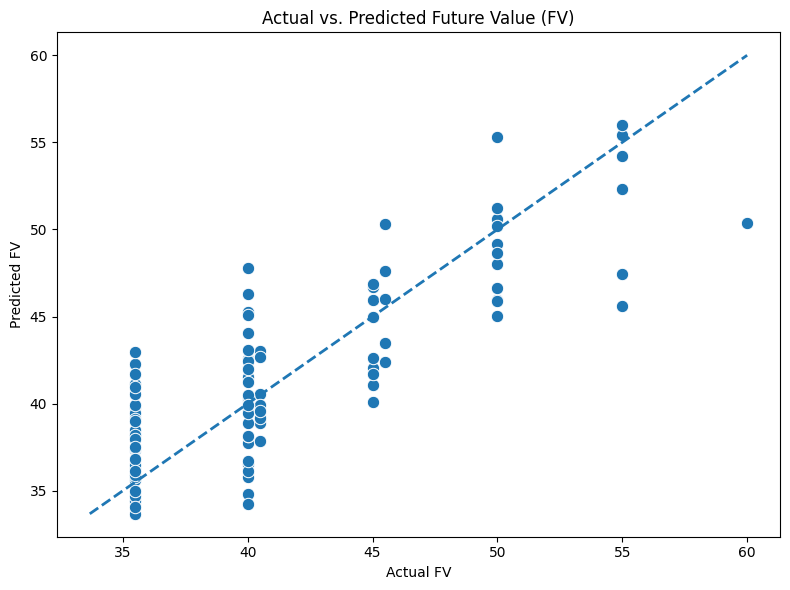

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create dataframe of actual vs predicted values
results_df = pd.DataFrame({
    "Actual_FV": y_test_fv.values,
    "Predicted_FV": fv_preds
})

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=results_df,
    x="Actual_FV",
    y="Predicted_FV",
    s=80
)

# Perfect prediction reference line
min_val = min(results_df["Actual_FV"].min(),
              results_df["Predicted_FV"].min())

max_val = max(results_df["Actual_FV"].max(),
              results_df["Predicted_FV"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

# Labels and title
plt.title("Actual vs. Predicted Future Value (FV)")
plt.xlabel("Actual FV")
plt.ylabel("Predicted FV")

plt.tight_layout()
plt.show()